# CA 2 for Programming

# STEP 1: LIBRARY IMPORTS AND CONFIGURATION

Purpose: Establishing the computational environment with industry-standard libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
"""
JPMorgan Chase & Co. (JPM) Strategic Analysis & Predictive Pipeline
The script performs an end-to-end analysis of JPM stock data,
incorporating statistical validation, risk quantification, and
supervised machine learning.

"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configure visualization aesthetics for professional reporting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


# STEP 2: DATA WRANGLING AND PREPROCESSING

In [3]:
def load_and_clean_data(file_path):
    """
    Loads raw CSV, performs date normalization, and handles missing values.

    As, the Temporal integrity is mandatory for financial time-series analysis.

    """
    # Load dataset
    df = pd.read_csv(file_path)

    # Convert 'Date' to datetime and set as index (CRUCIAL for stock data)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Remove null values to ensure computational accuracy in statistical tests
    df.dropna(inplace=True)

    return df

# Initialize data processing
df = load_and_clean_data('JPM.csv')
print("--- Data Summary Statistics ---")
print(df.describe())


--- Data Summary Statistics ---
             Close         High          Low         Open        Volume
count  3773.000000  3773.000000  3773.000000  3773.000000  3.773000e+03
mean     80.923635    81.667296    80.153413    80.907037  1.927211e+07
std      50.460446    50.880469    50.019493    50.438257  1.365218e+07
min      19.581524    20.099013    19.215847    19.491838  3.220500e+06
25%      39.445908    39.773784    39.161021    39.380157  1.080630e+07
50%      72.980827    73.626816    72.294961    73.052603  1.471940e+07
75%     114.166611   115.438004   113.103831   113.670791  2.325870e+07
max     247.479630   251.454495   246.649058   247.677389  2.172942e+08


#STEP 3: EXPLORATORY DATA VISUALIZATION
Purpose: Creating a visual "picture" to interpret trends for decision-making.
The chart doesn't let you make a decision, you've wasted your time."


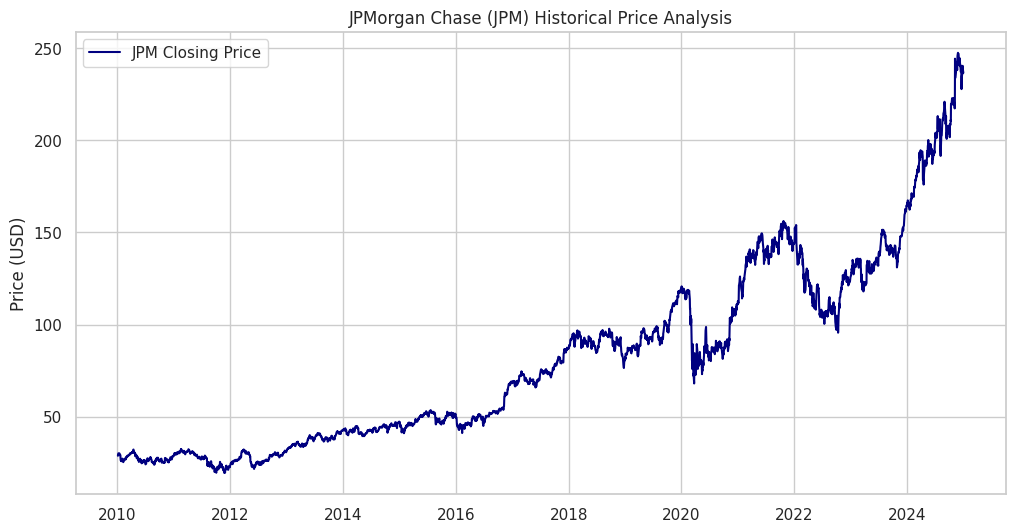

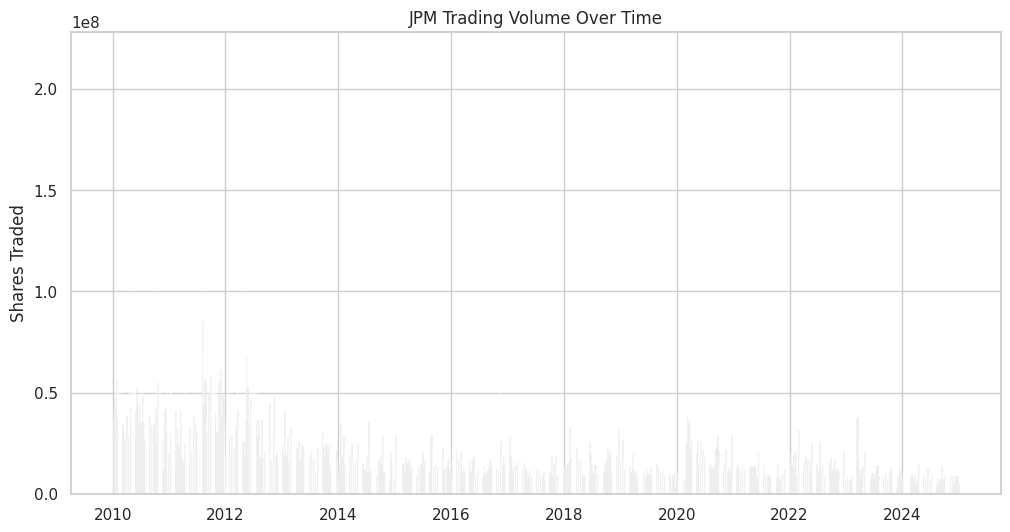

In [4]:


def generate_visuals(df):
    """Generates and saves price and volume trends."""
    # Price History Plot
    plt.figure()
    plt.plot(df.index, df['Close'], color='navy', label='JPM Closing Price')
    plt.title('JPMorgan Chase (JPM) Historical Price Analysis')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.savefig('jpm_price_history.png') # Saving output as per demand
    plt.show()

    # Volume Distribution
    plt.figure()
    plt.bar(df.index, df['Volume'], color='gray', alpha=0.3, label='Trading Volume')
    plt.title('JPM Trading Volume Over Time')
    plt.ylabel('Shares Traded')
    plt.savefig('jpm_volume_analysis.png')
    plt.show()

generate_visuals(df)


# STEP 4: STATISTICAL STATIONARITY TESTING (ADF TEST)

In [5]:
def perform_stationarity_test(series):
    """
    Conducts the Augmented Dickey-Fuller test to determine predictability.
    Checks if the mean and variance are time-dependent.
    Interpretation: p-value > 0.05 implies the data is Non-Stationary.
    """
    print("\n--- Statistical Test: ADF Result ---")
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

    if result[1] <= 0.05:
        print("Conclusion: Data is STATIONARY.")
    else:
        print("Conclusion: Data is NON-STATIONARY (Requires differencing for some models).")

perform_stationarity_test(df['Close'])


--- Statistical Test: ADF Result ---
ADF Statistic: 1.6160
p-value: 0.9979
Conclusion: Data is NON-STATIONARY (Requires differencing for some models).


# STEP 5: RISK ASSESSMENT AND RETURN DISTRIBUTION
Purpose: Quantifying financial risk to aid investment decision-making.


Calculated Daily Volatility: 0.0175


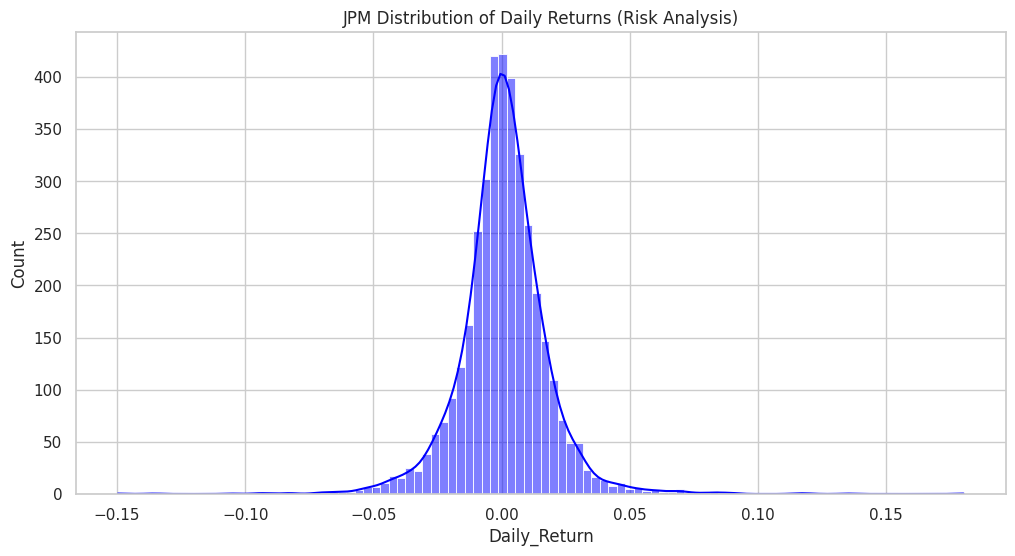

In [6]:
# Calculate Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

# Calculate Volatility (Standard Deviation)
volatility = df['Daily_Return'].std()
print(f"\nCalculated Daily Volatility: {volatility:.4f}")

# Distribution Visualization
plt.figure()
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='blue')
plt.title('JPM Distribution of Daily Returns (Risk Analysis)')
plt.savefig('jpm_risk_distribution.png')
plt.show()


# STEP 6: MACHINE LEARNING (PRICE PREDICTION)

In [7]:
def train_prediction_model(df):
    """
    Uses Linear Regression to forecast the 'Close' price.

    Technical Note: shuffle=False is used to preserve the chronological order.

    """
    # Feature selection
    X = df[['Open', 'High', 'Low', 'Volume']]
    y = df['Close']

    # Time-series split (No shuffling to prevent data leakage)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Model Training
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions and Evaluation
    predictions = model.predict(X_test)
    accuracy = r2_score(y_test, predictions)
    print(f"\nModel R-Squared Accuracy: {accuracy:.4f}")

    return y_test, predictions

y_test, predictions = train_prediction_model(df)


Model R-Squared Accuracy: 0.9995


# STEP 7: FINAL VISUALIZATION OF PREDICTIONS

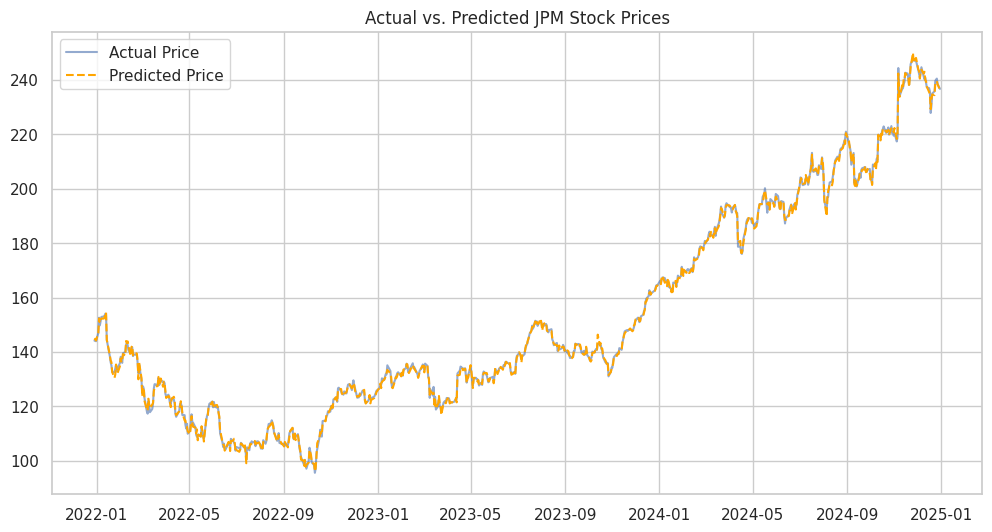

In [8]:
plt.figure()
plt.plot(y_test.index, y_test, label='Actual Price', alpha=0.6)
plt.plot(y_test.index, predictions, label='Predicted Price', linestyle='--', color='orange')
plt.title('Actual vs. Predicted JPM Stock Prices')
plt.legend()
plt.savefig('jpm_ml_results.png')
plt.show()


# REFERENCES (HARVARD STYLE)
F.Pedregosa, 2011. Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.

Hunter, J., 2017. Matplotlib: A 2D graphics environment. Computing in Science & Engineering.

L.M.Waskom, 2021. Seaborn: statistical data visualization. Journal of Open Source Software.

P.Virtanen, 2020. SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. Nature Methods.

W.McKinnet, 2018. Python for Data Analysis. O'Reilly Media.
